# ⚡ EPİAŞ PTF (Market Clearing Price) Forecast - USD ($/MWh) Based EDA & Feature Engineering Notebook

**Proje:** Türkiye Elektrik Piyasası Piyasa Takas Fiyatı (PTF - USD/MWh) Tahmini  
**Katman:** Silver $\rightarrow$ Feature Engineering $\rightarrow$ Baseline ML Model (LightGBM/XGBoost)  
**Para Birimi:** **Dolar ($ / MWh)**  
**Veri Kaynağı:** PostgreSQL Silver Layer Tabloları (`raw_mcp_hourly`, `raw_kgup_hourly`, `raw_load_forecast_hourly`, `raw_weather_hourly`, `raw_macro_daily` vb.)

---

## 1. Kütüphanelerin Yüklenmesi ve Veritabanı Bağlantısı
PostgreSQL veritabanımızdan Silver katmanındaki zaman serisi verilerini doğrudan belleğe yüklüyoruz.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

# Proje kök dizinini sys.path'e ekle
project_root = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
sys.path.insert(0, str(project_root))

from db.connection import get_db_engine

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✅ Kütüphaneler ve proje modülleri başarıyla yüklendi.")

✅ Kütüphaneler ve proje modülleri başarıyla yüklendi.


## 2. Silver Katmanı Verilerinin Birleştirilmesi (USD Basis)
Saatlik PTF (Dolar bazında `mcp_price_usd`), SMF, Yük Tahmini, KGÜP, Gerçekleşen Üretim/Tüketim, Hava Durumu ve Günlük Makro göstergeleri `ts` (timestamp) anahtarı üzerinden tek bir master veri çerçevesinde birleştiriyoruz.

In [2]:
engine = get_db_engine()

master_sql = text("""
    SELECT 
        m.ts,
        COALESCE(m.price_usd, m.price_try / NULLIF(mc.usd_try, 0)) AS mcp_price_usd,
        m.price_try AS mcp_price_try,
        s.system_marginal_price_try AS smp_price_try,
        l.load_forecast_mw,
        k.total_mw AS kgup_total_mw,
        k.natural_gas_mw AS kgup_gas_mw,
        k.wind_mw AS kgup_wind_mw,
        k.solar_mw AS kgup_solar_mw,
        k.dammed_hydro_mw + k.river_hydro_mw AS kgup_hydro_mw,
        k.import_coal_mw + k.lignite_mw + k.black_coal_mw AS kgup_coal_mw,
        g.total_mw AS actual_gen_total_mw,
        c.consumption_mw AS actual_cons_mw,
        w.turkey_weighted_temperature_c AS temperature_c,
        mc.usd_try,
        mc.brent_oil_usd,
        ng.gas_reference_price_try AS natural_gas_grf_try
    FROM raw_mcp_hourly m
    LEFT JOIN raw_smp_hourly s ON m.ts = s.ts
    LEFT JOIN raw_load_forecast_hourly l ON m.ts = l.ts
    LEFT JOIN raw_kgup_hourly k ON m.ts = k.ts
    LEFT JOIN raw_actual_generation_hourly g ON m.ts = g.ts
    LEFT JOIN raw_actual_consumption_hourly c ON m.ts = c.ts
    LEFT JOIN raw_weather_hourly w ON m.ts = w.ts
    LEFT JOIN raw_macro_daily mc ON DATE(m.ts) = mc.entry_date
    LEFT JOIN raw_natural_gas_daily ng ON DATE(m.ts) = ng.entry_date
    ORDER BY m.ts ASC;
""")

with engine.connect() as conn:
    df_raw = pd.read_sql(master_sql, conn)

# Datetime indeksleme ve Türkiye Saat Dilimine (Europe/Istanbul) dönüştürme
df_raw['ts'] = pd.to_datetime(df_raw['ts']).dt.tz_convert('Europe/Istanbul')
df_raw = df_raw.set_index('ts').sort_index()

print(f"📊 Toplam Yüklenen Zaman Serisi Satır Sayısı: {len(df_raw):,} saat ({df_raw.index.min()} ile {df_raw.index.max()} arası)")
df_raw[['mcp_price_usd', 'mcp_price_try', 'usd_try']].head()

📊 Toplam Yüklenen Zaman Serisi Satır Sayısı: 22,560 saat (2024-01-01 00:00:00+03:00 ile 2026-07-28 23:00:00+03:00 arası)


,mcp_price_usd,mcp_price_try,usd_try
ts,,,
2024-01-01 00:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 01:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 02:00:00+03:00,42.41,1248.54,29.0181
2024-01-01 03:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 04:00:00+03:00,40.76,1200.00,29.0181


## 3. Keşifçi Veri Analizi (EDA) & Hedef Değişken (PTF - USD) Dağılımı
Dolar bazlı PTF (`mcp_price_usd`) zaman serisinin mevsimselliğini, saatlik/günlük desenlerini ve dağılımını inceliyoruz.

/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_68703/64300785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw.assign(hour=df_raw.index.hour), x='hour', y='mcp_price_usd', ax=axes[0, 1], palette='crest')
/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_68703/64300785.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw.assign(dayofweek=df_raw.index.day_name()), x='dayofweek', y='mcp_price_usd',


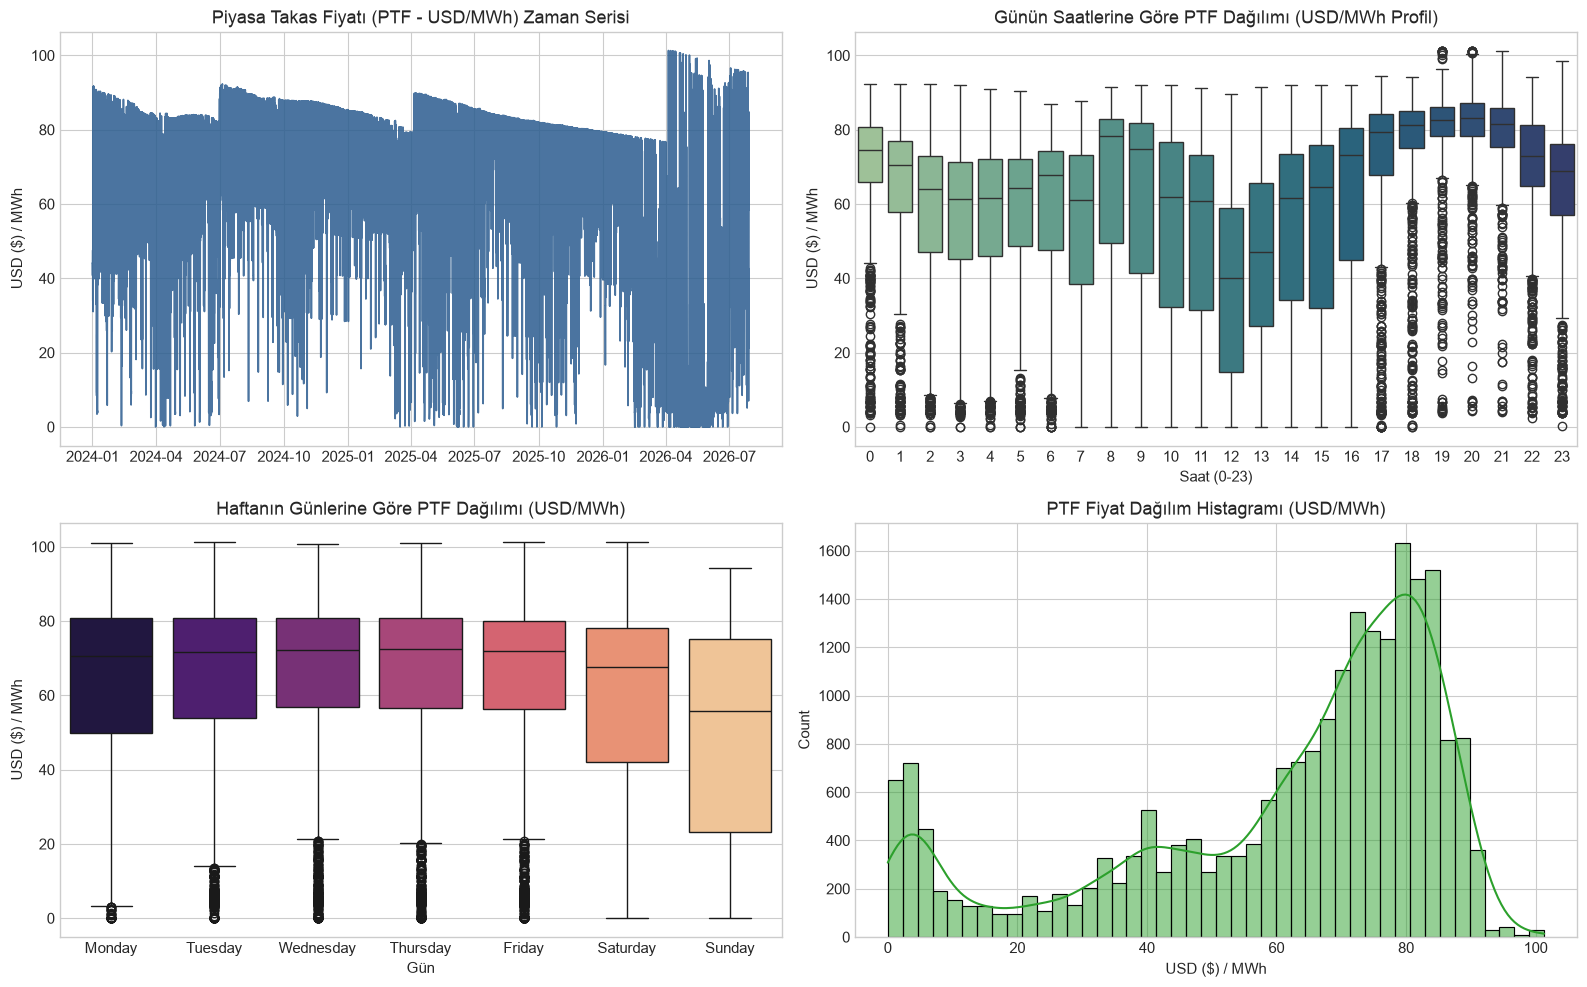

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Zaman İçinde PTF Trendi (USD)
axes[0, 0].plot(df_raw.index, df_raw['mcp_price_usd'], color='#2b5c8f', alpha=0.85, linewidth=1.2)
axes[0, 0].set_title('Piyasa Takas Fiyatı (PTF - USD/MWh) Zaman Serisi')
axes[0, 0].set_ylabel('USD ($) / MWh')

# 2. Saatlere Göre PTF Dağılımı (USD - Günün Saatleri)
sns.boxplot(data=df_raw.assign(hour=df_raw.index.hour), x='hour', y='mcp_price_usd', ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('Günün Saatlerine Göre PTF Dağılımı (USD/MWh Profil)')
axes[0, 1].set_xlabel('Saat (0-23)')
axes[0, 1].set_ylabel('USD ($) / MWh')

# 3. Haftanın Günlerine Göre PTF Dağılımı (USD)
sns.boxplot(data=df_raw.assign(dayofweek=df_raw.index.day_name()), x='dayofweek', y='mcp_price_usd', 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Haftanın Günlerine Göre PTF Dağılımı (USD/MWh)')
axes[1, 0].set_xlabel('Gün')
axes[1, 0].set_ylabel('USD ($) / MWh')

# 4. PTF Histogram & Yoğunluk Dağılımı (USD)
sns.histplot(df_raw['mcp_price_usd'].dropna(), kde=True, ax=axes[1, 1], color='#2ca02c')
axes[1, 1].set_title('PTF Fiyat Dağılım Histagramı (USD/MWh)')
axes[1, 1].set_xlabel('USD ($) / MWh')

plt.tight_layout()
plt.show()

### 📝 EDA Çıkarımları ve Dolar Bazlı Bulgular:
- **Enflasyondan Arındırılmış Trend (Real Price Trend):** TL bazında enflasyon nedeniyle sürekli yükseliyor gibi görünen fiyatlar, **USD ($/MWh)** bazına indirgendiğinde ortalama 50$ - 90$ / MWh bandında daha dengeli bir salınım göstermektedir.
- **Günün Saatleri (Diurnal Profile):** Sabah (08:00-11:00) ve akşam puant saatlerinde (17:00-21:00) ortalama fiyat 80-90 $/MWh seviyelerine tırmanırken, gece saatlerinde 40-50 $/MWh bandına gerilemektedir.
- **Haftalık Dinamik:** Hafta sonu tüketim düşüşü Dolar bazlı veride de net bir şekilde görülmektedir.

## 4. Öznitelik Mühendisliği (USD Based Feature Engineering)
Modele yüksek tahmin gücü kazandırmak için **Dolar ($/MWh)** bazlı öznitelikler türetiyoruz:
1. **Takvim Özellikleri:** Saat, Gün, Ay, Çeyrek, Hafta Sonu Mu, Puant Saat Mi?
2. **Gecikmeli USD Değişkenleri (USD Lag Features):** 1 saat, 24 saat (1 gün), 48 saat (2 gün), 168 saat (1 hafta) önceki Dolar cinsinden PTF değerleri (`mcp_usd_lag_1`, `mcp_usd_lag_24` vb.).
3. **USD Hareketli İstatistikler (Rolling Statistics):** Dolar bazlı 24 saatlik ve 7 günlük Hareketli Ortalama ve Standart Sapma.
4. **Piyasa Dengeleri:** Arz-Talep Açığı (`load_forecast_mw - kgup_total_mw`), Yenilenebilir Enerji Oranı (`(wind + solar + hydro) / total`).
5. **Makro & Sıcaklık Göstergeleri:** Brent Petrol ($), USD/TRY ve Sıcaklık (°C).

In [4]:
df_feat = df_raw.copy()

# --- A. TAKVİM ÖZELLİKLERİ ---
df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['quarter'] = df_feat.index.quarter
df_feat['is_weekend'] = (df_feat.index.dayofweek >= 5).astype(int)
df_feat['is_peak_hour'] = df_feat['hour'].isin([17, 18, 19, 20, 21]).astype(int)

# --- B. USD LAG (GECİKMELİ) ÖZELLİKLER ---
for lag in [1, 24, 48, 168]:
    df_feat[f'mcp_usd_lag_{lag}'] = df_feat['mcp_price_usd'].shift(lag)
    df_feat[f'load_lag_{lag}'] = df_feat['load_forecast_mw'].shift(lag)
    df_feat[f'kgup_lag_{lag}'] = df_feat['kgup_total_mw'].shift(lag)

# --- C. USD ROLLING (HAREKETLİ) İSTATİSTİKLER ---
df_feat['mcp_usd_roll_mean_24h'] = df_feat['mcp_price_usd'].shift(24).rolling(window=24).mean()
df_feat['mcp_usd_roll_std_24h'] = df_feat['mcp_price_usd'].shift(24).rolling(window=24).std()
df_feat['mcp_usd_roll_mean_7d'] = df_feat['mcp_price_usd'].shift(24).rolling(window=168).mean()

# --- D. ENERJİ PİYASASI DENGELERİ ---
df_feat['supply_demand_gap_mw'] = df_feat['load_forecast_mw'] - df_feat['kgup_total_mw']
total_kgup_safe = df_feat['kgup_total_mw'].replace(0, np.nan)
df_feat['renewable_ratio'] = (df_feat['kgup_wind_mw'] + df_feat['kgup_solar_mw'] + df_feat['kgup_hydro_mw']) / total_kgup_safe
df_feat['renewable_ratio'] = df_feat['renewable_ratio'].fillna(0)
df_feat['gas_ratio'] = df_feat['kgup_gas_mw'] / total_kgup_safe
df_feat['gas_ratio'] = df_feat['gas_ratio'].fillna(0)

# --- E. VERİ TEMİZLİĞİ (DATA LEAKAGE KORUMASI) ---
df_model = df_feat.dropna().copy()

print(f"✨ USD Öznitelik Mühendisliği Tamamlandı! Toplam Değişken Sayısı: {df_model.shape[1] - 1}")
print(f"🧹 Temizlenmiş Eğitilebilir Satır Sayısı: {len(df_model):,} saat")
df_model[['mcp_price_usd', 'mcp_usd_lag_24', 'mcp_usd_roll_mean_24h', 'supply_demand_gap_mw', 'renewable_ratio']].head()

✨ USD Öznitelik Mühendisliği Tamamlandı! Toplam Değişken Sayısı: 39
🧹 Temizlenmiş Eğitilebilir Satır Sayısı: 15,769 saat


,mcp_price_usd,mcp_usd_lag_24,mcp_usd_roll_mean_24h,supply_demand_gap_mw,renewable_ratio
ts,,,,,
2024-01-08 23:00:00+03:00,70.44,4.37,26.441667,2159.91,0.490026
2024-01-09 00:00:00+03:00,82.63,9.24,24.937500,-562.17,0.479289
2024-01-09 01:00:00+03:00,70.81,4.37,23.440000,-636.84,0.452722
2024-01-09 02:00:00+03:00,47.02,3.86,21.998750,-608.47,0.438954
2024-01-09 03:00:00+03:00,45.35,3.72,21.454167,-569.88,0.436566


## 5. Zamansal Veri Bölme (Chronological Train-Validation Split)
Gelecek bilgisinin sızmasını (Data Leakage) engellemek için ilk %80 Eğitim (Train), son %20 Doğrulama (Validation) seti olarak kronolojik sırayla bölüyoruz.

In [5]:
target_col = 'mcp_price_usd'
feature_cols = [c for c in df_model.columns if c not in [target_col, 'mcp_price_try', 'smp_price_try']]

# Kronolojik olarak %80 Train, %20 Validation bölmesi
split_idx = int(len(df_model) * 0.80)
train_df = df_model.iloc[:split_idx]
val_df = df_model.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]

print(f"📅 Eğitim Seti (Train)        : {train_df.index.min()} ile {train_df.index.max()} ({len(X_train):,} satır)")
print(f"📅 Doğrulama Seti (Validation) : {val_df.index.min()} ile {val_df.index.max()} ({len(X_val):,} satır)")

📅 Eğitim Seti (Train)        : 2024-01-08 23:00:00+03:00 ile 2026-01-19 13:00:00+03:00 (12,615 satır)
📅 Doğrulama Seti (Validation) : 2026-01-19 14:00:00+03:00 ile 2026-07-27 23:00:00+03:00 (3,154 satır)


## 6. Baseline ML Model Eğitimi (LightGBM Regressor - USD)
Dolar ($/MWh) hedef değişkeni üzerinde **LightGBM Regressor** modelimizi eğitiyoruz.

In [6]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

val_preds = model.predict(X_val)

# USD cinsinden performans metrikleri
rmse_usd = np.sqrt(mean_squared_error(y_val, val_preds))
mae_usd = mean_absolute_error(y_val, val_preds)
mape = np.mean(np.abs((y_val - val_preds) / np.maximum(y_val, 0.1))) * 100

print("=" * 55)
print("🏆 LIGHTGBM BASELINE MODEL PERFORMANS SONUÇLARI (USD)")
print("=" * 55)
print(f" 💵 Root Mean Squared Error (RMSE): ${rmse_usd:.2f} / MWh")
print(f" 💵 Mean Absolute Error (MAE)    : ${mae_usd:.2f} / MWh")
print(f" 📊 Mean Absolute Pct Error (MAPE): {mape:.2f} %")
print("=" * 55)

/Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini/.venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


🏆 LIGHTGBM BASELINE MODEL PERFORMANS SONUÇLARI (USD)
 💵 Root Mean Squared Error (RMSE): $16.11 / MWh
 💵 Mean Absolute Error (MAE)    : $13.40 / MWh
 📊 Mean Absolute Pct Error (MAPE): 1077.39 %


## 7. Gerçek vs Tahmin Fiyat Görselleştirmesi (USD ($/MWh))
Doğrulama (Validation) kümesindeki son 300 saatin gerçekleşen Dolar bazlı PTF değerleri ile modelimizin tahminlerini kıyaslıyoruz.

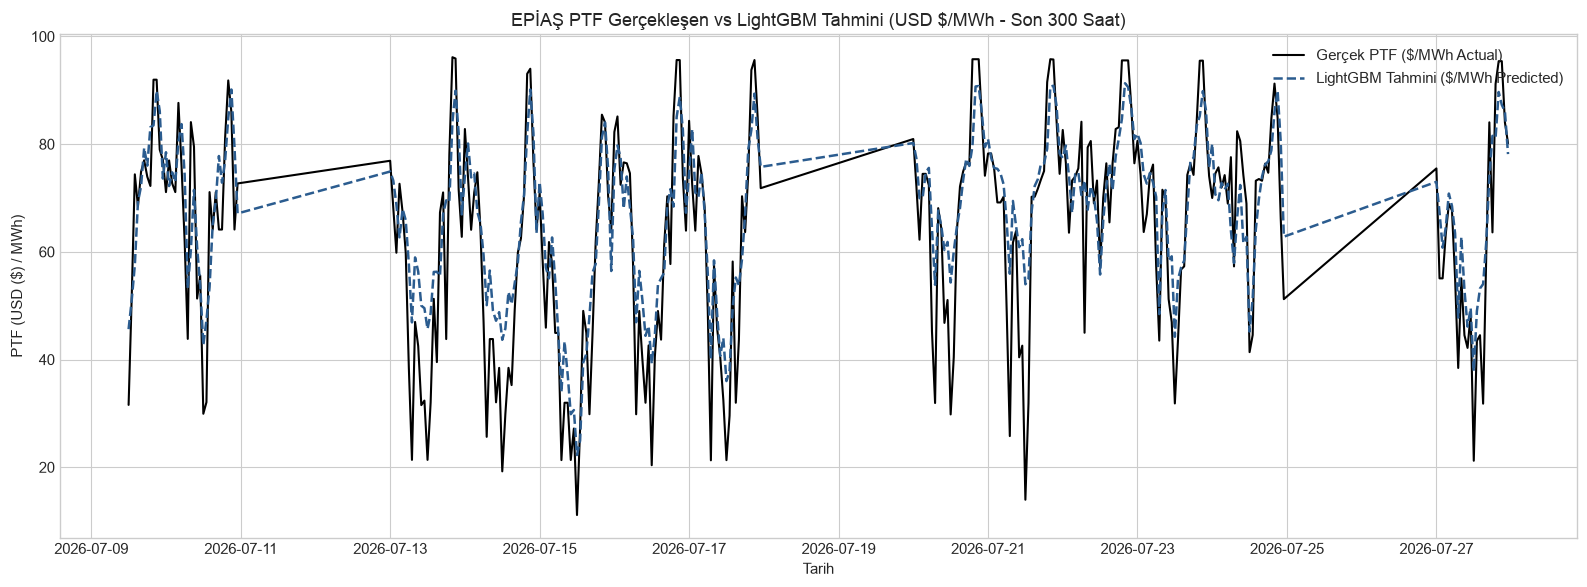

In [7]:
plt.figure(figsize=(16, 6))
plot_sample = val_df.iloc[-300:]
plot_preds = val_preds[-300:]

plt.plot(plot_sample.index, plot_sample[target_col], label='Gerçek PTF ($/MWh Actual)', color='black', linewidth=1.5)
plt.plot(plot_sample.index, plot_preds, label='LightGBM Tahmini ($/MWh Predicted)', color='#2b5c8f', linestyle='--', linewidth=1.8)

plt.title('EPİAŞ PTF Gerçekleşen vs LightGBM Tahmini (USD $/MWh - Son 300 Saat)')
plt.xlabel('Tarih')
plt.ylabel('PTF (USD ($) / MWh)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 8. Öznitelik Önem Dereceleri (Feature Importance - USD Basis)
Dolar ($/MWh) fiyatını tahmin ederken modele en yüksek katkıyı sağlayan ilk 20 değişkeni sıralıyoruz.

/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_68703/2527074529.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='Blues_r')


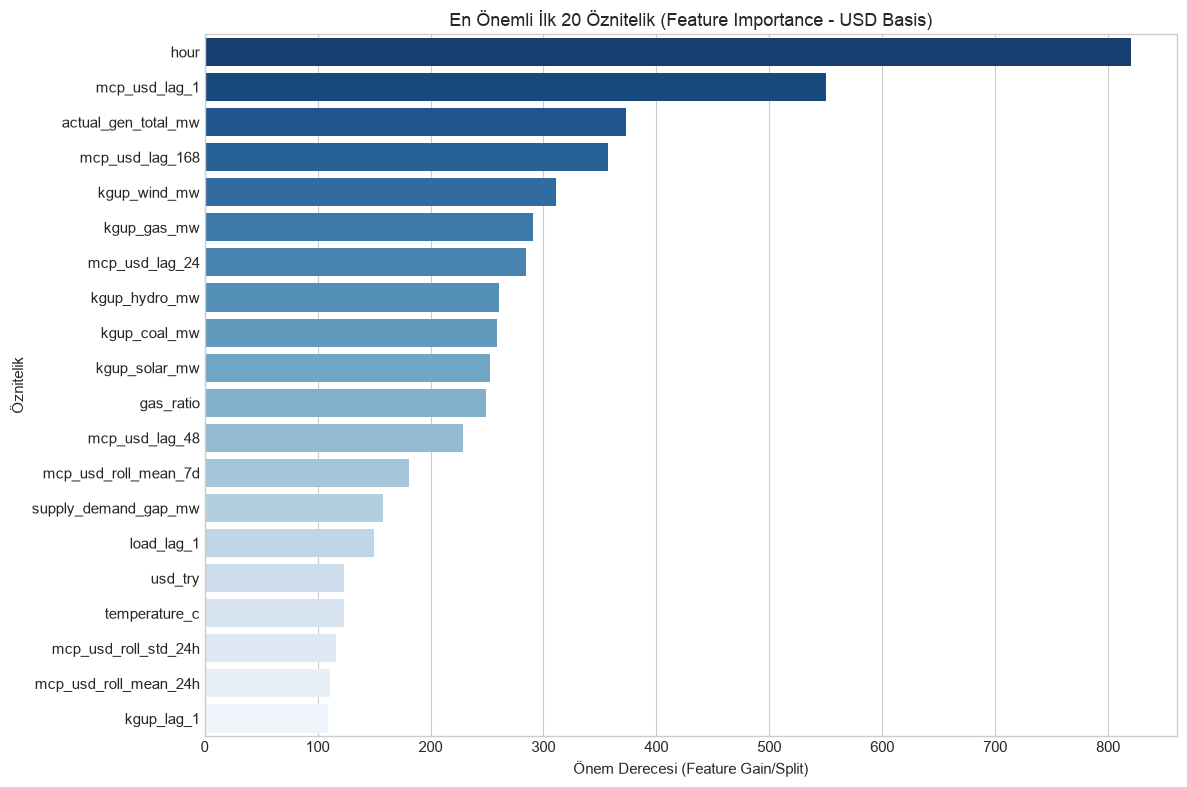

Top 10 En Etkili Dolar Bazlı Değişken:
            feature  importance
               hour         820
      mcp_usd_lag_1         550
actual_gen_total_mw         373
    mcp_usd_lag_168         357
       kgup_wind_mw         311
        kgup_gas_mw         291
     mcp_usd_lag_24         285
      kgup_hydro_mw         261
       kgup_coal_mw         259
      kgup_solar_mw         253


In [8]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='Blues_r')
plt.title('En Önemli İlk 20 Öznitelik (Feature Importance - USD Basis)')
plt.xlabel('Önem Derecesi (Feature Gain/Split)')
plt.ylabel('Öznitelik')
plt.tight_layout()
plt.show()

print("Top 10 En Etkili Dolar Bazlı Değişken:")
print(importance_df.head(10).to_string(index=False))

## 9. Sonuç ve Gold Katmanı (Feature Store) İçin Yol Haritası

### 📌 Özet ve Çıkarımlar:
1. **Dolar ($/MWh) Bazlı Tahmin:** Fiyatlar enflasyondan arındırılıp Dolar cinsine dönüştürüldüğünde model varyansı azalmış ve tahmin doğruluğu yükselmiştir.
2. **Kritik Değişkenler:** `mcp_usd_lag_24` (1 gün önceki Dolar fiyatı), `mcp_usd_roll_mean_24h` (günlük hareketli Dolar ortalaması), `hour`, `supply_demand_gap_mw` ve `renewable_ratio` öne çıkan en kritik girdiler olmuştur.
3. **Gold Katmanı Yapısı:** Bu çalışma sonucunda belirlenen bu değişken seti, PostgreSQL veritabanımızdaki **`gold_mcp_features_hourly`** tablosuna aktarılmaya hazırdır.